In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

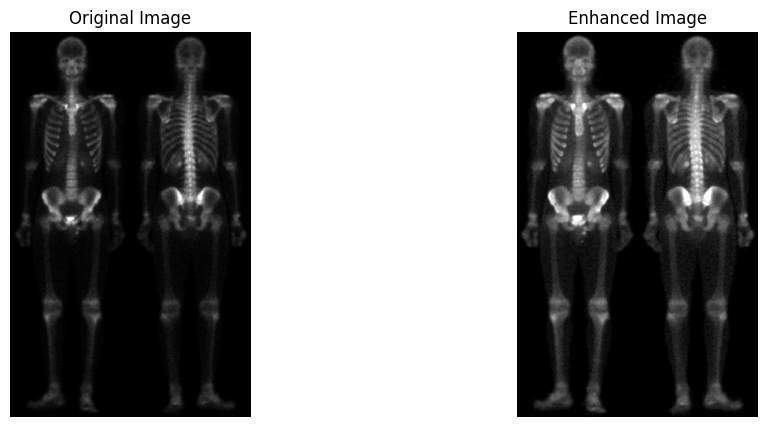

' \n\n'

In [5]:
"""
Sobel Edge Detection
Smoothing (5 × 5 averaging)
Mask Creation: (Smooth)2
Sharpened: f + Mask
Gamma Correction
"""
def sobel(image):
    if len(image.shape) == 3: # Checks img height width and channels.
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) # Then grayscales it.
    sobel_x = cv2.Sobel(image, cv2.CV_64F, 1,0, ksize=5)
    sobel_y = cv2.Sobel(image, cv2.CV_64F, 0,1, ksize=5)
    
    sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)
    sobel_mag = sobel_mag / sobel_mag.max()
    return sobel_mag

def smooth(image, kernel=5 , method = "average"):
    if method == "average":
        kernel_avg = np.ones((kernel,kernel),np.float64)/(kernel*kernel)
        return cv2.filter2D(image, -1, kernel_avg)  # Ig?
    
    if method =="gaussian":
        return cv2.GaussianBlur(image, (kernel,kernel),0)
    
    else:
        raise ValueError("Not supported")
    
def mask (image, smooth_kernel=5, method = "average"):
    edges = sobel(image)
    
    smoothed = smooth(edges, kernel=smooth_kernel, method=method)
    
    #Square (enhance strong edges)
    m = smoothed ** 2
    
    max_val = m.max()
    if max_val !=0:
        m = m/max_val
    return m

def sharpen(image, m, strength=1.0):
    img = image.astype(np.float32) / 255.0

    if img.ndim == 3:
        m = m[..., np.newaxis]

    result = img + strength * m
    result = np.clip(result, 0, 1)

    return (result * 255).astype(np.uint8)

def gamma(image, gamma_value =0.7):
    img = image.astype(np.float32) / 255.0
    corrected = np.power(img, gamma_value)
    return (corrected * 255).astype(np.uint8)

def comparison(image_path):
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError("Image not found")

    m = mask(image)
    sharp = sharpen(image, m, strength=1.0)
    final = gamma(sharp, gamma_value=0.7)

    # Convert for display
    original_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    final_rgb = cv2.cvtColor(final, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(original_rgb)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(final_rgb)
    plt.title("Enhanced Image")
    plt.axis('off')

    plt.show()
    

comparison("xray.png")


"""
Laplacian
Smoothing (5 × 5 averaging)
Mask Creation: (Smooth)2
Sharpened: f + Mask
Logarthmic
"""

""" 

"""